In [1]:
import pandas as pd
file=pd.read_csv('/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/training_solutions_rev1.zip')
df=pd.DataFrame(file)

df

,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.000000,0.000000,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.000000,0.000000,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.000000,0.000000,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61573,999948,0.510379,0.489621,0.000000,0.059207,0.430414,0.000000,0.430414,0.226257,0.204157,...,0.000000,0.226257,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.226257
61574,999950,0.901216,0.098784,0.000000,0.000000,0.098784,0.000000,0.098784,0.000000,0.098784,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
61575,999958,0.202841,0.777376,0.019783,0.116962,0.660414,0.067245,0.593168,0.140022,0.520391,...,0.000000,0.000000,0.090673,0.049349,0.000000,0.067726,0.000000,0.000000,0.0,0.072296
61576,999964,0.091000,0.909000,0.000000,0.045450,0.863550,0.022452,0.841098,0.795330,0.068220,...,0.000000,0.068398,0.318132,0.408799,0.227464,0.408799,0.090668,0.023065,0.0,0.045334


In [2]:
import zipfile
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import io

# Open the zip without fully extracting (saves disk space)
zip_path = '//kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/images_training_rev1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    # Get list of image filenames inside the zip
    image_files = [f for f in z.namelist()]# if f.endswith('.jpg')]
    print(f"Total training images: {len(image_files)}")
    print("Sample filenames:", image_files[:5])

Total training images: 61579
Sample filenames: ['images_training_rev1/', 'images_training_rev1/100008.jpg', 'images_training_rev1/100023.jpg', 'images_training_rev1/100053.jpg', 'images_training_rev1/100078.jpg']


In [3]:
import zipfile
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import io

# Open the zip without fully extracting (saves disk space)
zip_path = '//kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/images_training_rev1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    # Get list of image filenames inside the zip
    image_files = [f for f in z.namelist() if f.endswith('.jpg')]
    print(f"Total training images: {len(image_files)}")
    print("Sample filenames:", image_files[:5])

Total training images: 61578
Sample filenames: ['images_training_rev1/100008.jpg', 'images_training_rev1/100023.jpg', 'images_training_rev1/100053.jpg', 'images_training_rev1/100078.jpg', 'images_training_rev1/100090.jpg']


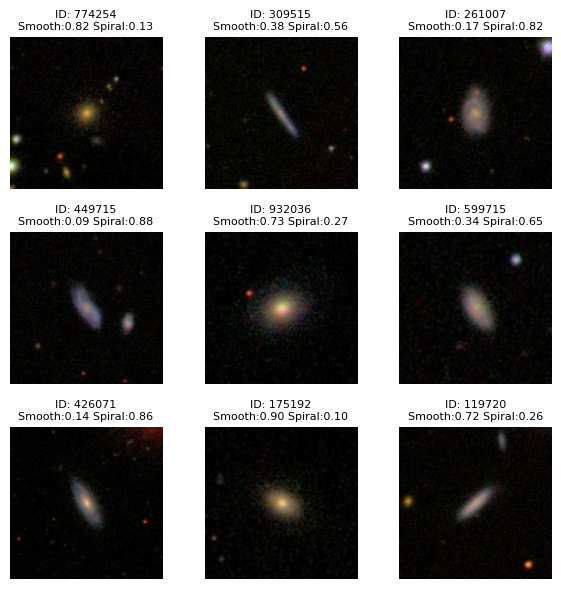

In [4]:
# Display 9 random galaxies with their label distributions
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

with zipfile.ZipFile(zip_path, 'r') as z:
    sample = df.sample(9, random_state=369)
    
    for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
        img_path = f'images_training_rev1/{int(row.GalaxyID)}.jpg'
        with z.open(img_path) as f:
            img = Image.open(io.BytesIO(f.read()))
            ax.imshow(img)
            ax.set_title(f"ID: {int(row['GalaxyID'])}\nSmooth:{row['Class1.1']:.2f} Spiral:{row['Class1.2']:.2f}", fontsize=8)
            ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('images_training_rev1/100008.jpg') as f:
        img = Image.open(io.BytesIO(f.read()))
        print("Size:", img.size)        # (width, height)
        print("Mode:", img.mode)        # RGB, L, etc
        print("Array shape:", np.array(img).shape)

Size: (424, 424)
Mode: RGB
Array shape: (424, 424, 3)


In [6]:
import random
with zipfile.ZipFile(zip_path, 'r') as z:
    sizes = set()
    rand=[random.randint(0,61578) for _ in range(20)]
    for i in rand:
        with z.open(image_files[i]) as f:
            img = Image.open(io.BytesIO(f.read()))
            sizes.add(img.size)
    print(sizes)

{(424, 424)}


In [7]:
def load_and_preprocess(galaxy_id, zip_ref, target_size=(64, 64)):
    img_path = f'images_training_rev1/{int(galaxy_id)}.jpg'
    with zip_ref.open(img_path) as f:
        img = Image.open(io.BytesIO(f.read())).resize(target_size)
        img = np.array(img) / 255.0  # normalize to 0-1
    return img

# Test it on one image
label_cols = [c for c in df.columns if c.startswith('Class')]

with zipfile.ZipFile(zip_path, 'r') as z:
    test_img = load_and_preprocess(100008, z)
    test_label = df[df.GalaxyID == 100008][label_cols].values[0]
    print("Image shape:", test_img.shape)
    print("Label shape:", test_label.shape)
    print("Pixel range:", test_img.min(), test_img.max())

Image shape: (64, 64, 3)
Label shape: (37,)
Pixel range: 0.0 0.8588235294117647


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class GalaxyDataset(Dataset):
    def __init__(self, dataframe, zip_path, label_cols, target_size=(128, 128), transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.zip_path = zip_path
        self.label_cols = label_cols
        self.target_size = target_size
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = f'images_training_rev1/{int(row["GalaxyID"])}.jpg'
        img = Image.open(img_path).resize(self.target_size)
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(np.array(img) / 255.0, dtype=torch.float32).permute(2, 0, 1)
        label = torch.tensor(row[self.label_cols].values.astype(np.float32))
        return img, label

In [9]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=369)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

train_dataset = GalaxyDataset(train_df, zip_path, label_cols, target_size=(128, 128))
val_dataset = GalaxyDataset(val_df, zip_path, label_cols, target_size=(128, 128))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 1540
Val batches: 385


In [10]:
import torch.nn as nn

class GalaxyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 37)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
class GalaxyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 37)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

In [13]:
import zipfile
extract_path = '/kaggle/working/images_training/'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/kaggle/working/')
    
print("Done extracting")

Done extracting


In [14]:
def load_and_preprocess(galaxy_id, target_size=(128, 128)):
    img_path = f'/kaggle/working/images_training_rev1/{int(galaxy_id)}.jpg'
    img = Image.open(img_path).resize(target_size)
    return np.array(img) / 255.0

In [15]:
from torchvision import transforms

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# No augmentation for validation, just normalize
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

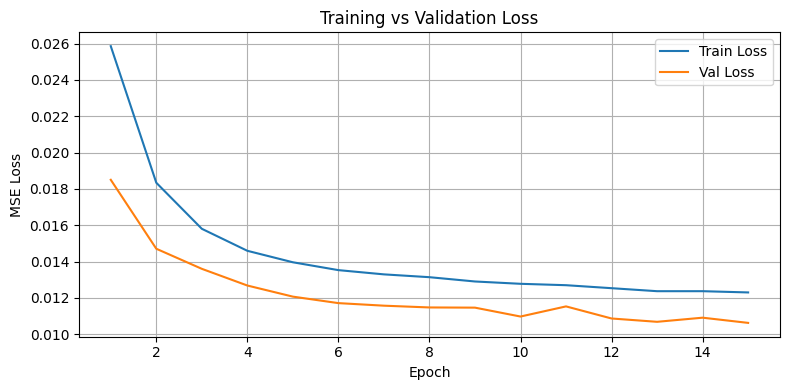

In [16]:
import torch.optim as optim
import torch
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

train_dataset = GalaxyDataset(train_df, zip_path, label_cols, target_size=(128,128), transform=train_transform)
val_dataset = GalaxyDataset(val_df, zip_path, label_cols, target_size=(128,128), transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

model = GalaxyCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
loss_fn = nn.MSELoss()

train_losses = []
val_losses = []

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(imgs)
        loss = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            predictions = model(imgs)
            loss = loss_fn(predictions, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

def plot_losses(train_losses, val_losses):
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for epoch in range(15):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    val_loss = validate(model, val_loader, loss_fn)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Val Loss={val_loss:.4f}")
    plot_losses(train_losses, val_losses)

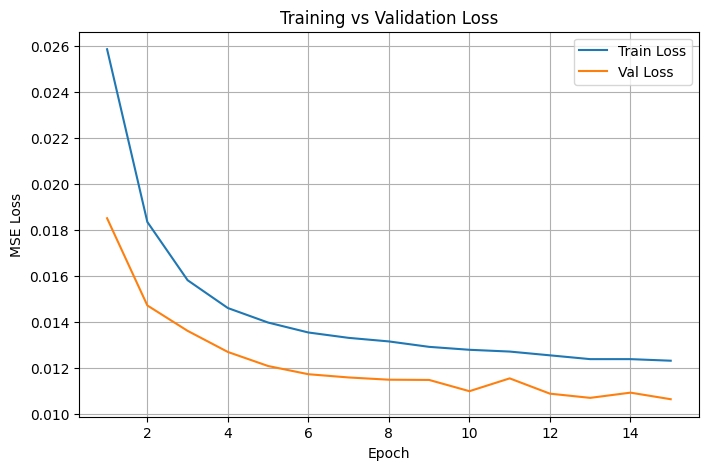

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, 16), train_losses, label='Train Loss')
plt.plot(range(1, 16), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()